<a href="https://colab.research.google.com/github/utkrasht23/CS771_Hardware_Security_Cryptanalysis/blob/main/Policy_Nexus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

Dataset Preparation

In [ ]:
nfhs4_path = "/content/drive/MyDrive/Policy Nexus/Data/IAHR74FL.DTA"
nfhs5_path = "/content/drive/MyDrive/Policy Nexus/Data/IAHR7EFL.DTA"

In [ ]:
sample4 = pd.read_stata(
    nfhs4_path,
    iterator=True
)

sample4 = sample4.get_chunk(5)

In [ ]:
sample5 = pd.read_stata(
    nfhs5_path,
    iterator=True
)

sample5 = sample5.get_chunk(5)

In [ ]:
print(sample4.shape)
print(sample5.shape)

(5, 5265)
(5, 6482)


In [ ]:
sample4.head()

,hhid,hv000,hv001,hv002,hv003,hv004,hv005,hv006,hv007,hv008,...,sh76_1,sh76_2,sh76_3,sh76_4,sh76_5,sh77_1,sh77_2,sh77_3,sh77_4,sh77_5
0,01000101,IA6,10001,1,3,1,191072,7,2015,1387,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01000109,IA6,10001,9,3,1,191072,7,2015,1387,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01000110,IA6,10001,10,2,1,191072,7,2015,1387,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01000111,IA6,10001,11,1,1,191072,7,2015,1387,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01000117,IA6,10001,17,2,1,191072,7,2015,1387,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
sample5.head()

,hhid,hv000,hv001,hv002,hv003,hv004,hv005,hv006,hv007,hv008,...,sh94_1,sh94_2,sh94_3,sh94_4,sh94_5,sh95_1,sh95_2,sh95_3,sh95_4,sh95_5
0,0100101305,IA7,113,5,1,113,196202,9,2019,1437,...,NaN,NaN,NaN,NaN,NaN,no,NaN,NaN,NaN,NaN
1,0100101345,IA7,113,45,1,113,196202,9,2019,1437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0100101383,IA7,113,83,1,113,196202,9,2019,1437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0100101334,IA7,113,34,1,113,196202,9,2019,1437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0100101356,IA7,113,56,1,113,196202,9,2019,1437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(sample4.columns.tolist())

['hhid', 'hv000', 'hv001', 'hv002', 'hv003', 'hv004', 'hv005', 'hv006', 'hv007', 'hv008', 'hv009', 'hv010', 'hv011', 'hv012', 'hv013', 'hv014', 'hv015', 'hv016', 'hv017', 'hv018', 'hv019', 'hv020', 'hv021', 'hv022', 'hv023', 'hv024', 'hv025', 'hv026', 'hv027', 'hv028', 'hv030', 'hv031', 'hv032', 'hv035', 'hv040', 'hv041', 'hv042', 'hv044', 'hv201', 'hv202', 'hv204', 'hv205', 'hv206', 'hv207', 'hv208', 'hv209', 'hv210', 'hv211', 'hv212', 'hv213', 'hv214', 'hv215', 'hv216', 'hv217', 'hv218', 'hv219', 'hv220', 'hv221', 'hv225', 'hv226', 'hv227', 'hv228', 'hv230a', 'hv230b', 'hv232', 'hv232b', 'hv232c', 'hv232d', 'hv232e', 'hv232y', 'hv234', 'hv234a', 'hv235', 'hv236', 'hv237', 'hv237a', 'hv237b', 'hv237c', 'hv237d', 'hv237e', 'hv237f', 'hv237g', 'hv237h', 'hv237i', 'hv237j', 'hv237k', 'hv237x', 'hv237z', 'hv238', 'hv239', 'hv240', 'hv241', 'hv242', 'hv243a', 'hv243b', 'hv243c', 'hv243d', 'hv244', 'hv245', 'hv246', 'hv246a', 'hv246b', 'hv246c', 'hv246d', 'hv246e', 'hv246f', 'hv246g', 'hv24

In [ ]:
print(sample5.columns.tolist())

['hhid', 'hv000', 'hv001', 'hv002', 'hv003', 'hv004', 'hv005', 'hv006', 'hv007', 'hv008', 'hv008a', 'hv009', 'hv010', 'hv011', 'hv012', 'hv013', 'hv014', 'hv015', 'hv016', 'hv017', 'hv018', 'hv019', 'hv020', 'hv021', 'hv022', 'hv023', 'hv024', 'hv025', 'hv026', 'hv027', 'hv028', 'hv030', 'hv031', 'hv032', 'hv035', 'hv040', 'hv041', 'hv042', 'hv044', 'hv045a', 'hv045b', 'hv045c', 'hv046', 'hv801', 'hv802', 'hv803', 'hv804', 'hv807d', 'hv807m', 'hv807y', 'hv807c', 'hv807a', 'hv201', 'hv202', 'hv201a', 'hv204', 'hv205', 'hv206', 'hv207', 'hv208', 'hv209', 'hv210', 'hv211', 'hv212', 'hv213', 'hv214', 'hv215', 'hv216', 'hv217', 'hv218', 'hv219', 'hv220', 'hv221', 'hv225', 'hv226', 'hv227', 'hv228', 'hv230a', 'hv230b', 'hv232', 'hv232b', 'hv232c', 'hv232d', 'hv232e', 'hv232y', 'hv234', 'hv234a', 'hv235', 'hv236', 'hv237', 'hv237a', 'hv237b', 'hv237c', 'hv237d', 'hv237e', 'hv237f', 'hv237g', 'hv237h', 'hv237i', 'hv237j', 'hv237k', 'hv237x', 'hv237z', 'hv238', 'hv238a', 'hv239', 'hv240', 'hv24

In [ ]:
required_cols = [
    "sh54", "sh55d", "sh58",
    "sh71", "sh72d", "sh75",
    "hv024", "hv025", "hv270",
    "hv009", "sh34", "sh35"
]

for col in required_cols:
    print(col,
          "NFHS-4:", col in sample4.columns,
          "| NFHS-5:", col in sample5.columns)

sh54 NFHS-4: True | NFHS-5: False
sh55d NFHS-4: True | NFHS-5: False
sh58 NFHS-4: True | NFHS-5: False
sh71 NFHS-4: True | NFHS-5: True
sh72d NFHS-4: False | NFHS-5: True
sh75 NFHS-4: False | NFHS-5: True
hv024 NFHS-4: True | NFHS-5: True
hv025 NFHS-4: True | NFHS-5: True
hv270 NFHS-4: True | NFHS-5: True
hv009 NFHS-4: True | NFHS-5: True
sh34 NFHS-4: True | NFHS-5: False
sh35 NFHS-4: True | NFHS-5: False


In [ ]:
for col in sample5.columns:
    if col.startswith("sh3"):
        print(col)

sh31
sh33a
sh33b
sh33c
sh33d
sh33a1a
sh33a1b
sh33a1c
sh33a1d
sh33a1e
sh33a1x
sh33b1a
sh33b1b
sh33b1c
sh33b1d
sh33b1e
sh33b1x
sh33c1a
sh33c1b
sh33c1c
sh33c1d
sh33c1e
sh33c1x
sh33d1a
sh33d1b
sh33d1c
sh33d1d
sh33d1e
sh33d1x
sh37b
sh305_01
sh305_02
sh305_03
sh305_04
sh305_05
sh305_06
sh305_07
sh305_08
sh305_09
sh305_10
sh305_11
sh305_12
sh305_13
sh305_14
sh305_15
sh305_16
sh305_17
sh305_18
sh305_19
sh305_20
sh305_21
sh305_22
sh305_23
sh305_24
sh305_25
sh305_26
sh305_27
sh305_28
sh305_29
sh305_30
sh305_31
sh305_32
sh305_33
sh305_34
sh305_35
sh306_01
sh306_02
sh306_03
sh306_04
sh306_05
sh306_06
sh306_07
sh306_08
sh306_09
sh306_10
sh306_11
sh306_12
sh306_13
sh306_14
sh306_15
sh306_16
sh306_17
sh306_18
sh306_19
sh306_20
sh306_21
sh306_22
sh306_23
sh306_24
sh306_25
sh306_26
sh306_27
sh306_28
sh306_29
sh306_30
sh306_31
sh306_32
sh306_33
sh306_34
sh306_35


In [ ]:
for col in sample5.columns:
    if col.startswith("sh4"):
        print(col)

sh44
sh45
sh46
sh47
sh48
sh49


In [ ]:
for col in sample5.columns:
    if col.startswith("sh5"):
        print(col)

sh50b
sh50c
sh50d
sh50e
sh50f
sh50g
sh50i
sh50j
sh50k
sh50n
sh50q
sh50r
sh50x
sh50y
sh50z
sh52
sh55
sh56a
sh56b
sh56c
sh56d
sh56e
sh56f
sh56x


In [ ]:
sample4[["sh54", "sh71"]].head()

,sh54,sh71
0,no,NaN
1,no,NaN
2,no,NaN
3,no,NaN
4,no,NaN


In [ ]:
sample5[["sh71"]].head()

,sh71
0,no
1,no
2,no
3,no
4,no


In [ ]:
reader4 = pd.read_stata(nfhs4_path, iterator=True)
reader5 = pd.read_stata(nfhs5_path, iterator=True)

print(reader4.variable_labels().get("sh54"))
print(reader4.variable_labels().get("sh55d"))
print(reader4.variable_labels().get("sh58"))
print(reader4.variable_labels().get("sh71"))

print("-"*60)

print(reader5.variable_labels().get("sh71"))
print(reader5.variable_labels().get("sh72d"))
print(reader5.variable_labels().get("sh75"))

member of household covered by a health scheme or health insurance
health scheme/insurance: rashtriya swasthya bima yojana (rsby)
household has a bpl card
total number of deaths since january 2011
------------------------------------------------------------
is any usual member of this household covered by a health scheme or health insur
health insurance or scheme: rashtriya swasthya bima yojana
does this household have a bpl card?


In [ ]:
reader = pd.read_stata(
    nfhs4_path,
    iterator=True,
    convert_categoricals=False
)

chunk = reader.get_chunk(5)

chunk.head()

,hhid,hv000,hv001,hv002,hv003,hv004,hv005,hv006,hv007,hv008,...,sh76_1,sh76_2,sh76_3,sh76_4,sh76_5,sh77_1,sh77_2,sh77_3,sh77_4,sh77_5
0,01000101,IA6,10001,1,3,1,191072,7,2015,1387,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01000109,IA6,10001,9,3,1,191072,7,2015,1387,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01000110,IA6,10001,10,2,1,191072,7,2015,1387,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01000111,IA6,10001,11,1,1,191072,7,2015,1387,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01000117,IA6,10001,17,2,1,191072,7,2015,1387,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import psutil

print(psutil.virtual_memory())

svmem(total=13605830656, available=11697569792, percent=14.0, used=1593810944, free=7143641088, active=628678656, inactive=5519568896, buffers=145240064, cached=4723138560, shared=2301952, slab=175153152)


In [ ]:
!pip install -q pyarrow

In [ ]:
import pyarrow as pa
import pyarrow.parquet as pq
import gc

In [ ]:
def extract_to_parquet(file_path, columns_to_keep, output_path, chunk_size=50000):

    reader = pd.read_stata(
        file_path,
        iterator=True,
        convert_categoricals=False
    )

    writer = None
    chunk_no = 0
    total_rows = 0

    while True:

        try:
            chunk = reader.get_chunk(chunk_size)

            # Keep only required columns
            chunk = chunk.loc[:, columns_to_keep].copy()

            # Convert to Arrow Table
            table = pa.Table.from_pandas(chunk, preserve_index=False)

            # Create writer once
            if writer is None:
                writer = pq.ParquetWriter(
                    output_path,
                    table.schema
                )

            # Write chunk
            writer.write_table(table)

            chunk_no += 1
            total_rows += len(chunk)

            print(f"Chunk {chunk_no} | Total rows: {total_rows}")

            del chunk
            del table
            gc.collect()

        except StopIteration:
            break

    if writer:
        writer.close()

    print("\nFinished!")

In [ ]:
cols_nfhs4 = [
    "sh54",
    "sh55d",
    "sh58",
    "hv024",
    "hv025",
    "hv270",
    "hv009"
]

extract_to_parquet(
    nfhs4_path,
    cols_nfhs4,
    "/content/drive/MyDrive/Policy Nexus/Data/nfhs4_small.parquet"
)

Chunk 1 | Total rows: 50000
Chunk 2 | Total rows: 100000
Chunk 3 | Total rows: 150000
Chunk 4 | Total rows: 200000
Chunk 5 | Total rows: 250000
Chunk 6 | Total rows: 300000
Chunk 7 | Total rows: 350000
Chunk 8 | Total rows: 400000
Chunk 9 | Total rows: 450000
Chunk 10 | Total rows: 500000
Chunk 11 | Total rows: 550000
Chunk 12 | Total rows: 600000
Chunk 13 | Total rows: 601509

Finished!


In [ ]:
nfhs4_small = pd.read_parquet(
    "/content/drive/MyDrive/Policy Nexus/Data/nfhs4_small.parquet"
)

print(nfhs4_small.shape)
nfhs4_small.head()

(601509, 7)


,sh54,sh55d,sh58,hv024,hv025,hv270,hv009
0,0,NaN,0,1,1,3,4
1,0,NaN,0,1,1,4,3
2,0,NaN,0,1,1,4,4
3,0,NaN,0,1,1,4,3
4,0,NaN,0,1,1,3,2


In [ ]:
nfhs4_small.rename(columns={
    "sh54": "insurance",
    "sh55d": "pmjay",
    "sh58": "bpl"
}, inplace=True)

nfhs4_small["wave"] = 0

In [ ]:
nfhs4_small.to_parquet(
    "/content/drive/MyDrive/Policy Nexus/Data/nfhs4_small.parquet",
    index=False
)

In [ ]:
del nfhs4_small
gc.collect()

0

In [ ]:
cols_nfhs5 = [
    "sh71",
    "sh72d",
    "sh75",
    "hv024",
    "hv025",
    "hv270",
    "hv009"
]

extract_to_parquet(
    nfhs5_path,
    cols_nfhs5,
    "/content/drive/MyDrive/Policy Nexus/Data/nfhs5_small.parquet"
)

Chunk 1 | Total rows: 50000
Chunk 2 | Total rows: 100000
Chunk 3 | Total rows: 150000
Chunk 4 | Total rows: 200000
Chunk 5 | Total rows: 250000
Chunk 6 | Total rows: 300000
Chunk 7 | Total rows: 350000
Chunk 8 | Total rows: 400000
Chunk 9 | Total rows: 450000
Chunk 10 | Total rows: 500000
Chunk 11 | Total rows: 550000
Chunk 12 | Total rows: 600000
Chunk 13 | Total rows: 636699

Finished!


In [ ]:
nfhs5_small = pd.read_parquet(
    "/content/drive/MyDrive/Policy Nexus/Data/nfhs5_small.parquet"
)

print(nfhs5_small.shape)

nfhs5_small.head()

(636699, 7)


,sh71,sh72d,sh75,hv024,hv025,hv270,hv009
0,0,0,1,1,2,3,5
1,0,0,1,1,2,3,4
2,0,0,1,1,2,3,5
3,0,0,1,1,2,1,5
4,0,0,1,1,2,3,6


In [ ]:
nfhs5_small.rename(columns={
    "sh71":"insurance",
    "sh72d":"pmjay",
    "sh75":"bpl"
}, inplace=True)

nfhs5_small["wave"] = 1

nfhs5_small.to_parquet(
    "/content/drive/MyDrive/Policy Nexus/Data/nfhs5_small.parquet",
    index=False
)

del nfhs5_small
gc.collect()

0

In [ ]:
nfhs4 = pd.read_parquet("/content/drive/MyDrive/Policy Nexus/Data/nfhs4_small.parquet")
nfhs5 = pd.read_parquet("/content/drive/MyDrive/Policy Nexus/Data/nfhs5_small.parquet")

df = pd.concat([nfhs4, nfhs5], ignore_index=True)

print(df.shape)

(1238208, 8)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1238208 entries, 0 to 1238207
Data columns (total 8 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   insurance  1238208 non-null  int8   
 1   pmjay      792230 non-null   float64
 2   bpl        1238208 non-null  int8   
 3   hv024      1238208 non-null  int8   
 4   hv025      1238208 non-null  int8   
 5   hv270      1238208 non-null  int8   
 6   hv009      1238208 non-null  int8   
 7   wave       1238208 non-null  int64  
dtypes: float64(1), int64(1), int8(6)
memory usage: 26.0 MB


In [ ]:
df.isnull().sum()

,0
insurance,0
pmjay,445978
bpl,0
hv024,0
hv025,0
hv270,0
hv009,0
wave,0


In [ ]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(10))


insurance
insurance
0    804663
1    426741
8      6804
Name: count, dtype: int64

pmjay
pmjay
0.0    678447
NaN    445978
1.0    110594
8.0      3189
Name: count, dtype: int64

bpl
bpl
0    696076
1    539879
8      2253
Name: count, dtype: int64

hv024
hv024
33    104162
9      72233
19     70229
29     61489
23     54949
20     49753
5      48941
24     40581
21     38191
10     37422
Name: count, dtype: int64

hv025
hv025
2    902124
1    336084
Name: count, dtype: int64

hv270
hv270
1    280500
2    271108
3    250974
4    227420
5    208206
Name: count, dtype: int64

hv009
hv009
4     276611
5     230538
3     188016
6     154631
2     142312
7      84296
1      52797
8      45342
9      25783
10     15669
Name: count, dtype: int64

wave
wave
1    636699
0    601509
Name: count, dtype: int64


In [ ]:
df.describe(include='all')

,insurance,pmjay,bpl,hv024,hv025,hv270,hv009,wave
count,1.238208e+06,792230.000000,1.238208e+06,1.238208e+06,1.238208e+06,1.238208e+06,1.238208e+06,1.238208e+06
mean,3.886043e-01,0.171801,4.505729e-01,1.899207e+01,1.728572e+00,2.847945e+00,4.613894e+00,5.142101e-01
std,7.384535e-01,0.606387,5.911454e-01,1.009038e+01,4.446964e-01,1.399376e+00,2.225951e+00,4.997982e-01
min,0.000000e+00,0.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000,0.000000e+00,1.000000e+01,1.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000,0.000000e+00,1.900000e+01,2.000000e+00,3.000000e+00,4.000000e+00,1.000000e+00
75%,1.000000e+00,0.000000,1.000000e+00,2.800000e+01,2.000000e+00,4.000000e+00,6.000000e+00,1.000000e+00
max,8.000000e+00,8.000000,8.000000e+00,3.700000e+01,2.000000e+00,5.000000e+00,4.100000e+01,1.000000e+00


Feature Engineering

In [ ]:
# -----------------------------
# Target variable
# -----------------------------
df["insured"] = df["insurance"].replace(8, np.nan)

# -----------------------------
# PM-JAY / RSBY
# -----------------------------
df["pmjay"] = df["pmjay"].replace(8, np.nan)

# -----------------------------
# BPL
# -----------------------------
df["bpl"] = df["bpl"].replace(8, np.nan)

# -----------------------------
# Wealth category
# -----------------------------
wealth_map = {
    1: "Poor",
    2: "Poor",
    3: "Middle",
    4: "Rich",
    5: "Rich"
}

df["wealth_cat"] = df["hv270"].map(wealth_map)

# -----------------------------
# Urban / Rural
# -----------------------------
urban_map = {
    1: "Urban",
    2: "Rural"
}

df["urban_rural"] = df["hv025"].map(urban_map)

In [ ]:
print(df[["insured", "pmjay", "bpl"]].isnull().sum())

print(df["insured"].value_counts(dropna=False))
print(df["pmjay"].value_counts(dropna=False))
print(df["bpl"].value_counts(dropna=False))

insured      6804
pmjay      449167
bpl          2253
dtype: int64
insured
0.0    804663
1.0    426741
NaN      6804
Name: count, dtype: int64
pmjay
0.0    678447
NaN    449167
1.0    110594
Name: count, dtype: int64
bpl
0.0    696076
1.0    539879
NaN      2253
Name: count, dtype: int64


In [ ]:
df.head()

df[[
    "insured",
    "pmjay",
    "bpl",
    "wealth_cat",
    "urban_rural"
]].head()

,insured,pmjay,bpl,wealth_cat,urban_rural
0,0.0,NaN,0.0,Middle,Urban
1,0.0,NaN,0.0,Rich,Urban
2,0.0,NaN,0.0,Rich,Urban
3,0.0,NaN,0.0,Rich,Urban
4,0.0,NaN,0.0,Middle,Urban


In [ ]:
df.to_parquet(
    "/content/drive/MyDrive/Policy Nexus/Data/final_dataset.parquet",
    index=False
)

In [ ]:
df.to_csv(
    "/content/drive/MyDrive/Policy Nexus/Data/final_dataset.csv",
    index=False
)

EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

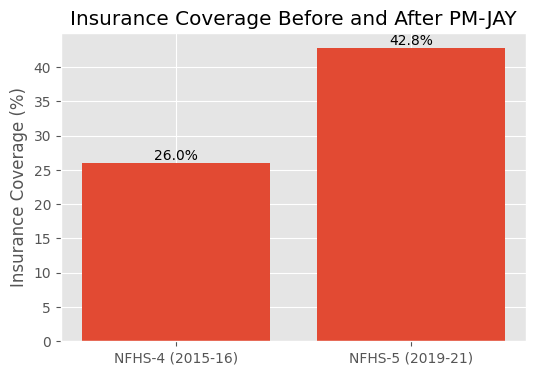

In [ ]:
coverage = (
    df.groupby("wave")["insured"]
      .mean()
      .reset_index()
)

coverage["wave"] = coverage["wave"].map({
    0: "NFHS-4 (2015-16)",
    1: "NFHS-5 (2019-21)"
})

plt.figure(figsize=(6,4))

plt.bar(
    coverage["wave"],
    coverage["insured"]*100
)

plt.ylabel("Insurance Coverage (%)")
plt.title("Insurance Coverage Before and After PM-JAY")

for i,v in enumerate(coverage["insured"]*100):
    plt.text(i,v+0.5,f"{v:.1f}%",ha="center")

plt.show()

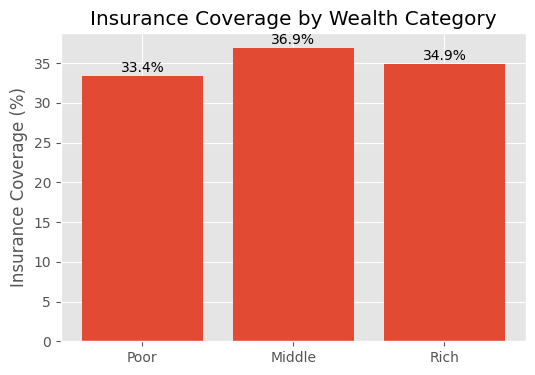

In [ ]:
wealth = (
    df.groupby("wealth_cat")["insured"]
      .mean()
      .reindex(["Poor","Middle","Rich"])
      .reset_index()
)

plt.figure(figsize=(6,4))

plt.bar(
    wealth["wealth_cat"],
    wealth["insured"]*100
)

plt.ylabel("Insurance Coverage (%)")
plt.title("Insurance Coverage by Wealth Category")

for i,v in enumerate(wealth["insured"]*100):
    plt.text(i,v+0.5,f"{v:.1f}%",ha="center")

plt.show()

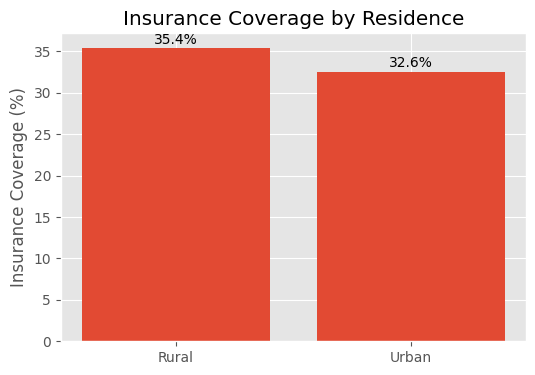

In [ ]:
urban = (
    df.groupby("urban_rural")["insured"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(6,4))

plt.bar(
    urban["urban_rural"],
    urban["insured"]*100
)

plt.ylabel("Insurance Coverage (%)")
plt.title("Insurance Coverage by Residence")

for i,v in enumerate(urban["insured"]*100):
    plt.text(i,v+0.5,f"{v:.1f}%",ha="center")

plt.show()

In [ ]:
state_map = {
    1: "J&K",
    2: "HP",
    3: "Punjab",
    4: "Chandigarh",
    5: "Uttarakhand",
    6: "Haryana",
    7: "Delhi",
    8: "Rajasthan",
    9: "UP",
    10: "Bihar",
    11: "Sikkim",
    12: "Arunachal",
    13: "Nagaland",
    14: "Manipur",
    15: "Mizoram",
    16: "Tripura",
    17: "Meghalaya",
    18: "Assam",
    19: "West Bengal",
    20: "Jharkhand",
    21: "Odisha",
    22: "Chhattisgarh",
    23: "MP",
    24: "Gujarat",
    25: "Daman & Diu",
    26: "DNH",
    27: "Maharashtra",
    28: "Andhra",
    29: "Karnataka",
    30: "Goa",
    31: "Lakshadweep",
    32: "Kerala",
    33: "Tamil Nadu",
    34: "Puducherry",
    35: "A&N Islands",
    36: "Telangana"
}

df["state"] = df["hv024"].map(state_map)

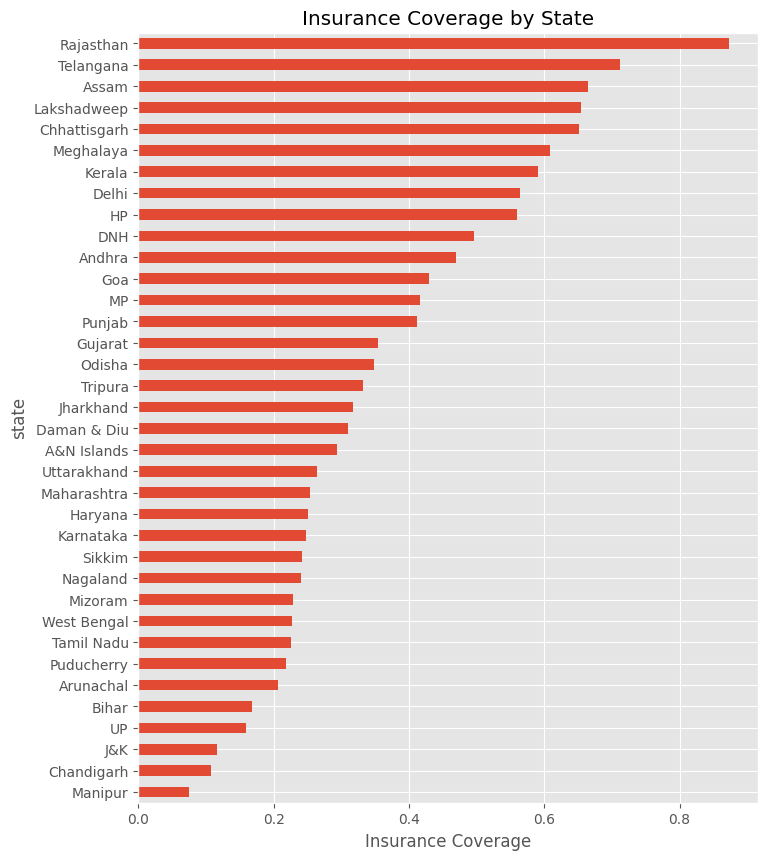

In [ ]:
state = (
    df.groupby("state")["insured"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(8,10))

state.plot(kind="barh")

plt.xlabel("Insurance Coverage")
plt.title("Insurance Coverage by State")

plt.show()

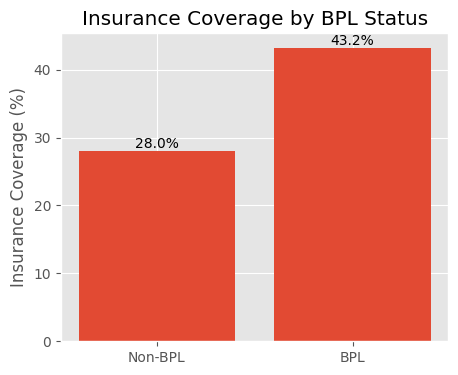

In [ ]:
bpl = (
    df.groupby("bpl")["insured"]
      .mean()
      .reset_index()
)

bpl["bpl"] = bpl["bpl"].map({
    0:"Non-BPL",
    1:"BPL"
})

plt.figure(figsize=(5,4))

plt.bar(
    bpl["bpl"],
    bpl["insured"]*100
)

plt.ylabel("Insurance Coverage (%)")
plt.title("Insurance Coverage by BPL Status")

for i,v in enumerate(bpl["insured"]*100):
    plt.text(i,v+0.5,f"{v:.1f}%",ha="center")

plt.show()

Observations-


*   Insurance coverage increased from 26.0% in NFHS-4 to 42.8% in NFHS-5, therefore a substantial improvement in health insurance
*   Middle-income households show the highest insurance coverage, while poor households have the lowest coverage among the three


*   Rural households exhibit slightly higher insurance coverage than urban households in the combined dataset
*   Insurance coverage varies considerably across states, with Rajasthan and Telangana showing the highest coverage


*   BPL households have higher insurance coverage than non-BPL households







Difference-in-Differences

Treatment group = BPL households and
Control group = Non-BPL households




In [ ]:
# Treatment group
df["treated"] = df["bpl"]

# Interaction term
df["did_term"] = df["treated"] * df["wave"]

In [ ]:
import statsmodels.formula.api as smf

did_model = smf.ols(
    formula="""
    insured ~ treated + wave + did_term
              + C(wealth_cat)
              + C(urban_rural)
              + hv009
    """,
    data=df
).fit()

In [ ]:
print(did_model.summary())

                            OLS Regression Results                            
Dep. Variable:                insured   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                 1.045e+04
Date:                Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:30:55   Log-Likelihood:            -7.9601e+05
No. Observations:             1229429   AIC:                         1.592e+06
Df Residuals:                 1229421   BIC:                         1.592e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [ ]:
print("DiD Coefficient:", did_model.params["did_term"])
print("P-value:", did_model.pvalues["did_term"])

DiD Coefficient: -0.02380594794740779
P-value: 7.268497320144568e-45


As B=-0.02 and Pvalue=7.26 -> increase in insurance coverage among BPL households was slightly lower than that observed for non-BPL households after PM-JAY

XGBoost

Target variable -> Insured

In [ ]:
ml_df = df.copy()

In [ ]:
ml_df["pmjay"] = ml_df["pmjay"].fillna(0)
ml_df["insured"] = ml_df["insured"].fillna(0)
ml_df["bpl"] = ml_df["bpl"].fillna(0)

In [ ]:
print(ml_df[["insured","pmjay","bpl"]].isnull().sum())

insured    0
pmjay      0
bpl        0
dtype: int64


In [ ]:
features = [
    "bpl",
    "hv009",
    "wealth_cat",
    "urban_rural",
    "state",
    "wave"
]

X = ml_df[features]

y = ml_df["insured"]

Encoding categorical variables

In [ ]:
X = pd.get_dummies(
    X,
    columns=[
        "wealth_cat",
        "urban_rural",
        "state"
    ],
    drop_first=True
)

In [ ]:
print(X.shape)

(1238208, 41)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
!pip install -q xgboost

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7625079752222967
Precision: 0.7033613831792891
Recall   : 0.5376575901017012
F1 Score : 0.6094469051524348
ROC-AUC  : 0.8056751236496638


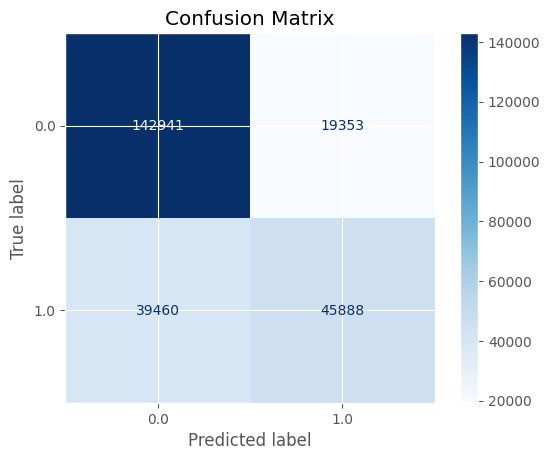

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

SHAP Analysis

In [ ]:
!pip install -q shap

In [ ]:
import shap
explainer = shap.TreeExplainer(model)

In [ ]:
X_sample = X_test.sample(
    3000,
    random_state=42
)

In [ ]:
shap_values = explainer.shap_values(X_sample)

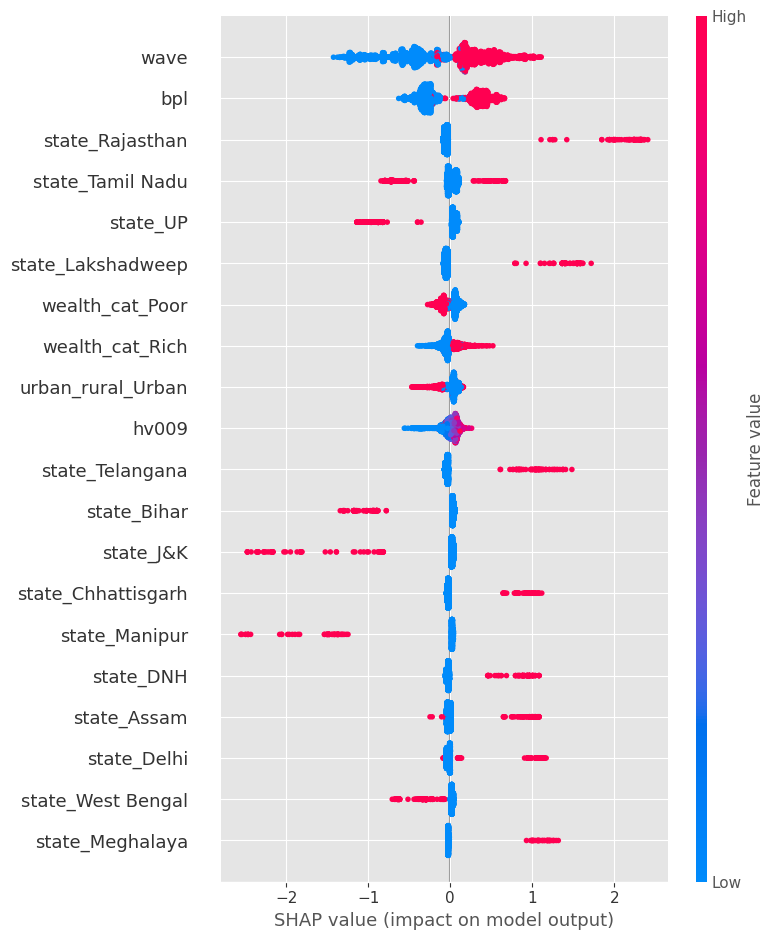

In [ ]:
shap.summary_plot(
    shap_values,
    X_sample
)

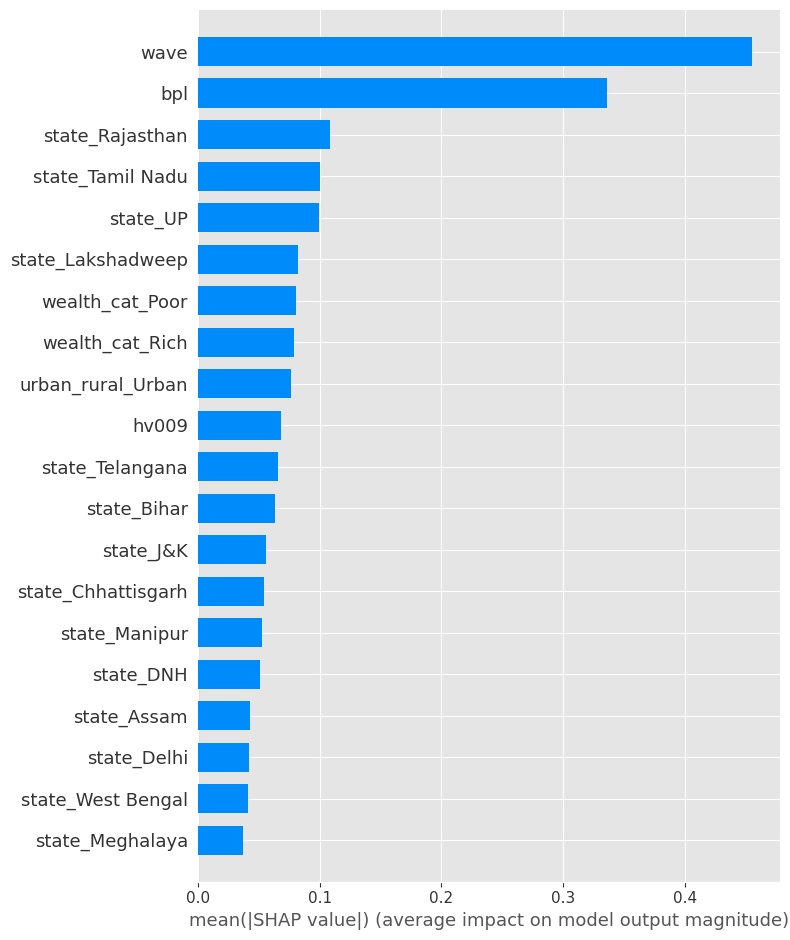

In [ ]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

The survey period / wave (NFHS-4 vs. NFHS-5) emerged as the most influential predictor -> households surveyed during the post-PM-JAY period had a substantially higher likelihood of being insured than those surveyed before the scheme's implementation

Conclusions:


*   Health insurance coverage increased substantially from 26.0% (NFHS-4) to 42.8% (NFHS-5), indicating a significant improvement in insurance implementation during the post-PM-JAY survey period
*   As B=-0.02 and Pvalue=7.26 -> increase in insurance coverage among BPL households was slightly lower than that observed for non-BPL households after PM-JAY

*   The XGBoost classifier achieved an accuracy of 76.25% and an ROC-AUC score of 0.806
*   SHAP analysis showed that survey period (wave), BPL status, and state of residence were the most influential predictors of insurance coverage








Policy Recommendations:


*   Adopt state-specific implementation strategies, as insurance coverage patterns differ significantly across states
*   Improve targeting of non-BPL households that remain uninsured while continuing support for economically vulnerable families

